Loaded:
 - outputs_baseline/baseline_df.csv
 - outputs_topology_augmented/topology_augmented_df.csv
Selected lambda: 2.0

Pretreatment sample:
  first date: 2009-01-01
  last  date: 2011-03-01
  n periods : 27


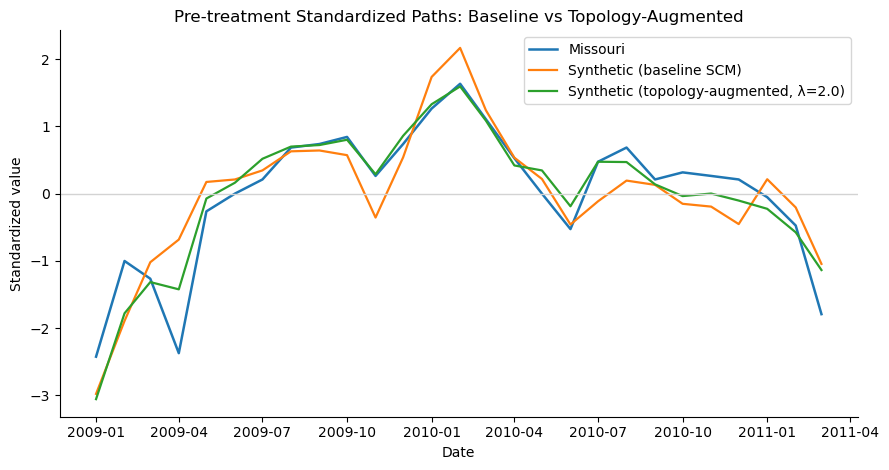


Running topology-augmented TDA check for embedding (3,1)
treated point cloud shape : (25, 3)
baseline point cloud shape: (25, 3)
topo point cloud shape    : (25, 3)


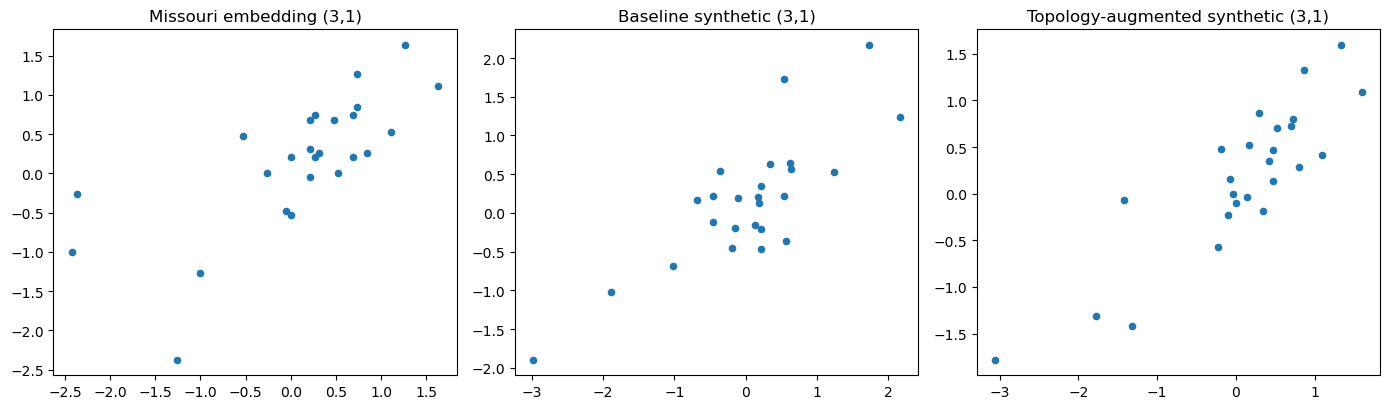

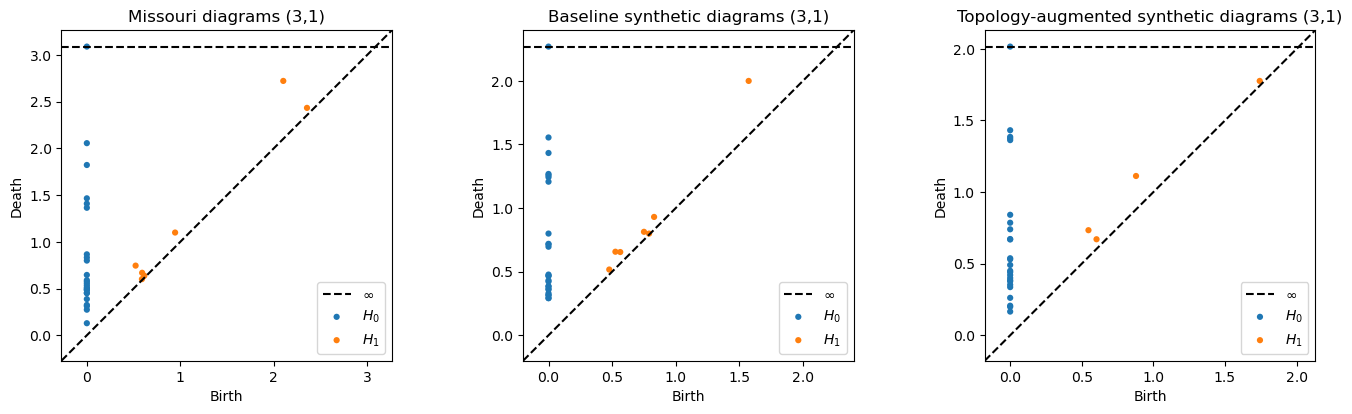

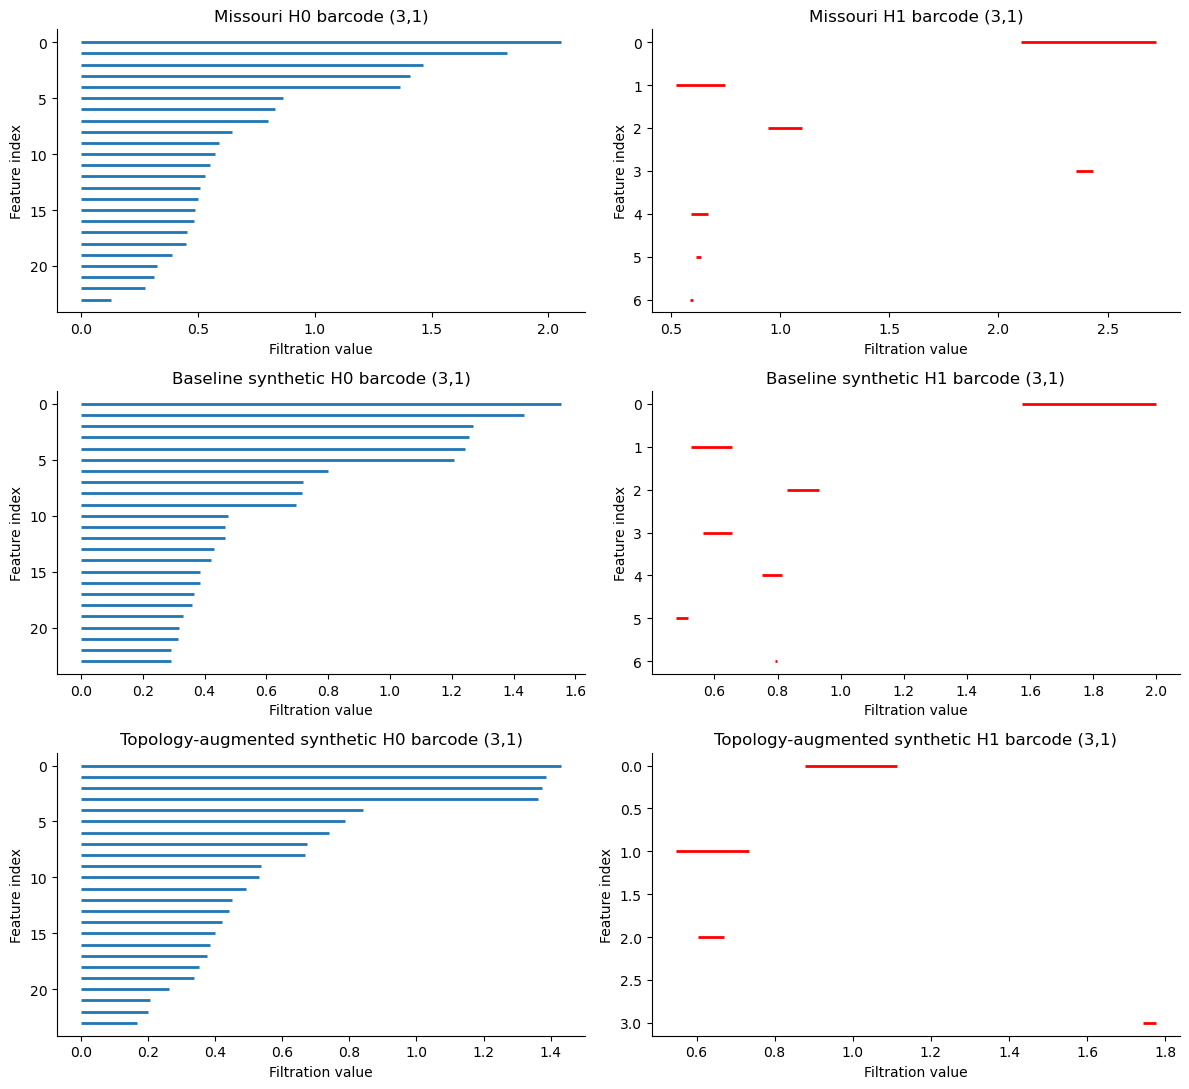


Embedding (3,1) summary
Missouri H1 summary: {'n_features': 7, 'max_persistence': 0.6197268962860107, 'total_persistence': 1.1870372295379639, 'mean_persistence': 0.16957674707685197}
Baseline synthetic H1 summary: {'n_features': 7, 'max_persistence': 0.4260373115539551, 'total_persistence': 0.858764111995697, 'mean_persistence': 0.12268058742795672}
Topology-augmented synthetic H1 summary: {'n_features': 4, 'max_persistence': 0.23361682891845703, 'total_persistence': 0.5220217108726501, 'mean_persistence': 0.13050542771816254}
H1 wasserstein baseline : 1.197382963477928
H1 wasserstein topo     : 0.6467851413792702
H1 absolute reduction   : 0.5505978220986578
H1 percent reduction    : 45.983435449873696

Running topology-augmented TDA check for embedding (2,1)
treated point cloud shape : (26, 2)
baseline point cloud shape: (26, 2)
topo point cloud shape    : (26, 2)


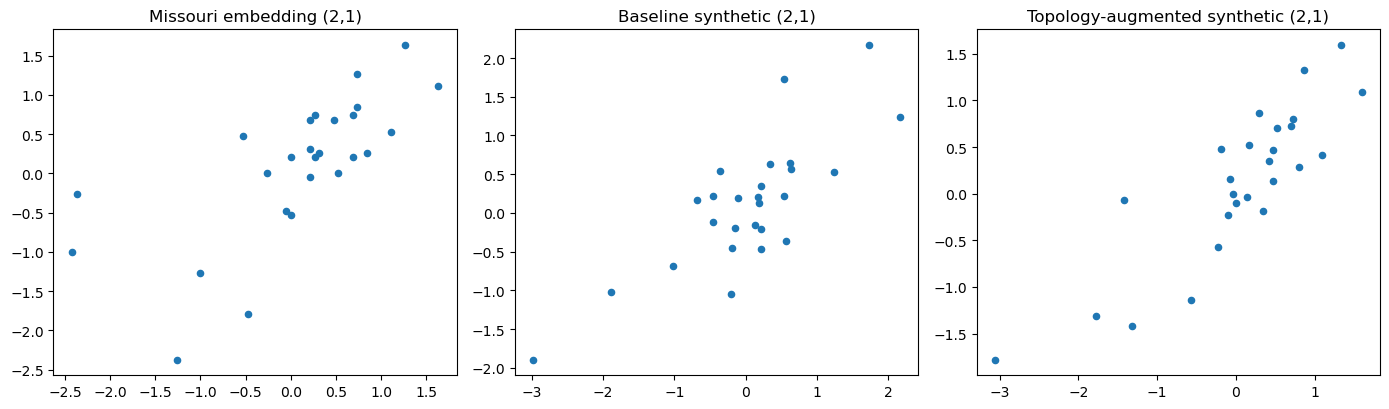

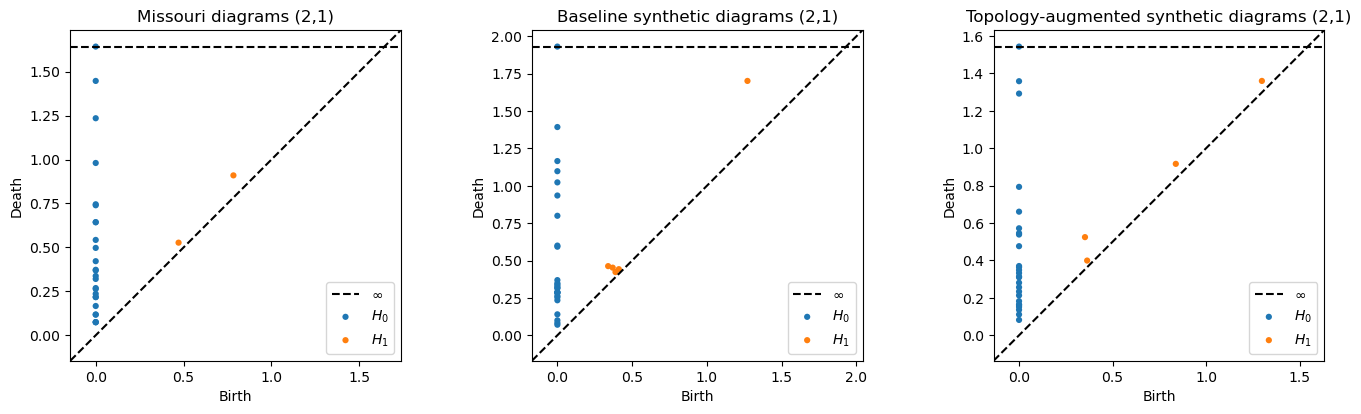

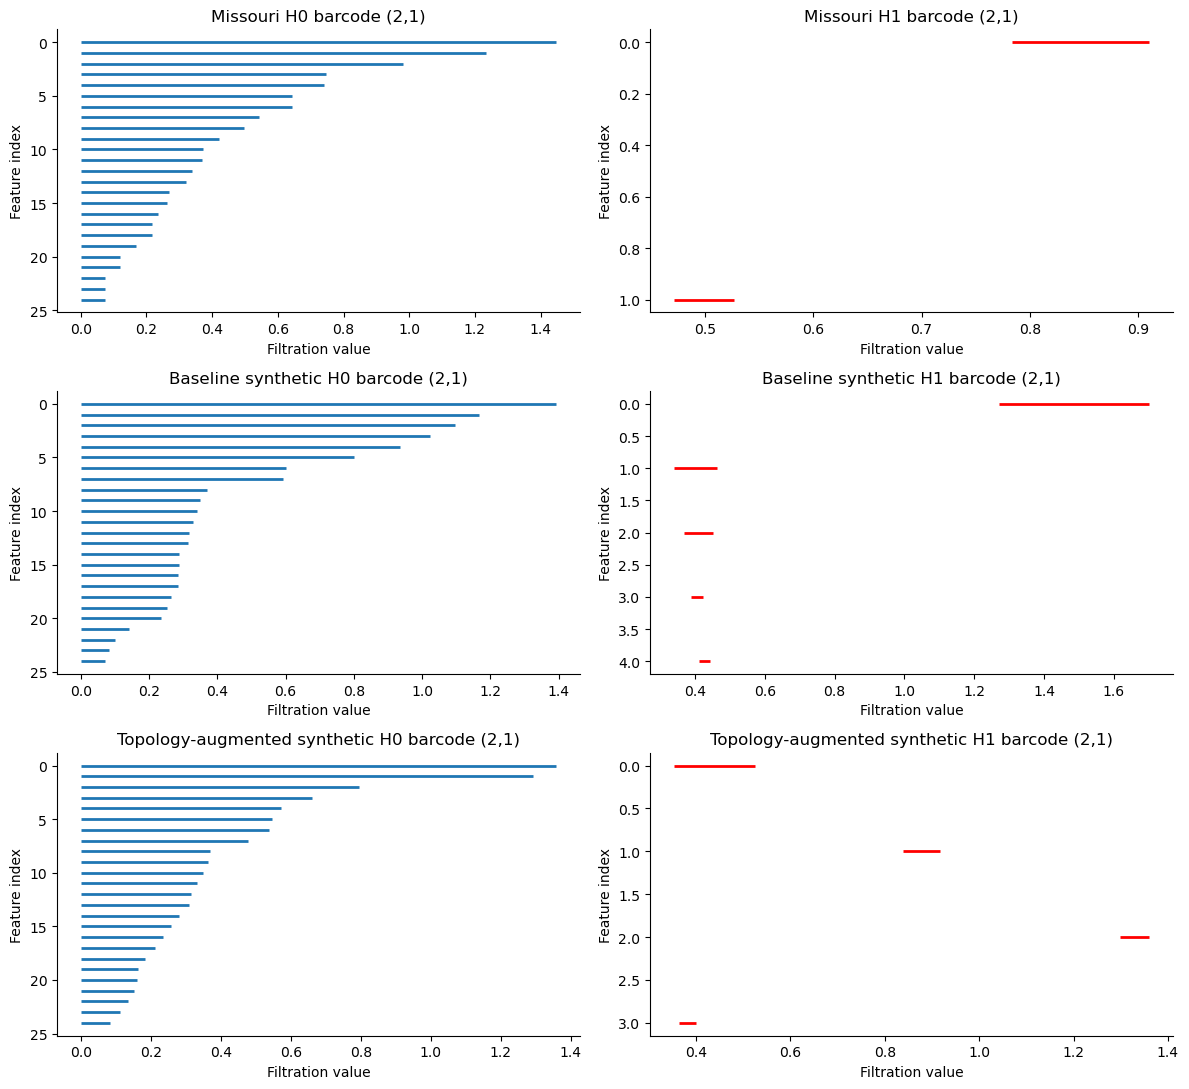


Embedding (2,1) summary
Missouri H1 summary: {'n_features': 2, 'max_persistence': 0.12631350755691528, 'total_persistence': 0.1819554567337036, 'mean_persistence': 0.0909777283668518}
Baseline synthetic H1 summary: {'n_features': 5, 'max_persistence': 0.42984652519226074, 'total_persistence': 0.7004926204681396, 'mean_persistence': 0.14009852409362794}
Topology-augmented synthetic H1 summary: {'n_features': 4, 'max_persistence': 0.1722736358642578, 'total_persistence': 0.34783482551574707, 'mean_persistence': 0.08695870637893677}
H1 wasserstein baseline : 0.6239850194344537
H1 wasserstein topo     : 0.24256844692112978
H1 absolute reduction   : 0.38141657251332395
H1 percent reduction    : 61.12591819255842

=== TOPOLOGY-AUGMENTED TDA CHECK SUMMARY ===
embedding  dim  delay  n_points  selected_lambda  MO_H0_n  MO_H0_maxpers  MO_H0_totalpers  MO_H0_meanpers  MO_H1_n  MO_H1_maxpers  MO_H1_totalpers  MO_H1_meanpers  BASE_H0_n  BASE_H0_maxpers  BASE_H0_totalpers  BASE_H0_meanpers  BASE_H1

In [5]:
# ============================================================
# 07_topology_augmented_tda_check
# Purpose:
#   - Missouri-only TDA re-check after topology-augmented SCM
#   - compare baseline SCM vs topology-augmented SCM
#   - run TDA under:
#       (3,1) main specification
#       (2,1) robustness specification
#   - save all plots and summary tables
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ripser import ripser
from persim import plot_diagrams, bottleneck, wasserstein

# ------------------------------------------------------------
# 0) Paths
# ------------------------------------------------------------
BASELINE_DIR = "outputs_baseline"
TOPO_DIR = "outputs_topology_augmented"
OUTPUT_DIR = "outputs_topology_augmented_tda_check"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BASELINE_DF_PATH = os.path.join(BASELINE_DIR, "baseline_df.csv")
TOPO_DF_PATH = os.path.join(TOPO_DIR, "topology_augmented_df.csv")
SELECTED_LAMBDA_PATH = os.path.join(TOPO_DIR, "selected_lambda.json")
METRICS_PATH = os.path.join(TOPO_DIR, "baseline_vs_topology_augmented_metrics.csv")

# ------------------------------------------------------------
# 1) Load data
# ------------------------------------------------------------
baseline_df = pd.read_csv(BASELINE_DF_PATH)
baseline_df["date"] = pd.to_datetime(baseline_df["date"])

topology_augmented_df = pd.read_csv(TOPO_DF_PATH)
topology_augmented_df["date"] = pd.to_datetime(topology_augmented_df["date"])

selected_lambda = None
if os.path.exists(SELECTED_LAMBDA_PATH):
    with open(SELECTED_LAMBDA_PATH, "r", encoding="utf-8") as f:
        selected_lambda = json.load(f).get("selected_lambda", None)

comparison_metrics = None
if os.path.exists(METRICS_PATH):
    comparison_metrics = pd.read_csv(METRICS_PATH)

print("Loaded:")
print(" -", BASELINE_DF_PATH)
print(" -", TOPO_DF_PATH)
if selected_lambda is not None:
    print("Selected lambda:", selected_lambda)

# ------------------------------------------------------------
# 2) Basic settings
# ------------------------------------------------------------
TREATMENT_START = pd.Timestamp("2011-04-01")
EMBEDDING_SPECS = [
    (3, 1),   # main
    (2, 1),   # robustness
]

# ------------------------------------------------------------
# 3) Merge baseline and topology-augmented paths
# ------------------------------------------------------------
needed_baseline = ["mo_yr", "date", "treated", "synthetic_baseline", "gap_centered_baseline"]
needed_topo = ["mo_yr", "date", "synthetic_topology_augmented", "gap_centered_topology_augmented"]

missing_baseline = [c for c in needed_baseline if c not in baseline_df.columns]
missing_topo = [c for c in needed_topo if c not in topology_augmented_df.columns]

if missing_baseline:
    raise ValueError(f"baseline_df is missing columns: {missing_baseline}")
if missing_topo:
    raise ValueError(f"topology_augmented_df is missing columns: {missing_topo}")

compare_df = baseline_df[needed_baseline].merge(
    topology_augmented_df[needed_topo],
    on=["mo_yr", "date"],
    how="inner"
).sort_values("date").reset_index(drop=True)

compare_df.to_csv(os.path.join(OUTPUT_DIR, "baseline_vs_topology_augmented_compare_df.csv"), index=False)

# ------------------------------------------------------------
# 4) Pretreatment series
# ------------------------------------------------------------
pre_levels = compare_df.loc[
    compare_df["date"] < TREATMENT_START,
    ["date", "treated", "synthetic_baseline", "synthetic_topology_augmented"]
].copy().reset_index(drop=True)

print("\nPretreatment sample:")
print("  first date:", pre_levels["date"].min().date())
print("  last  date:", pre_levels["date"].max().date())
print("  n periods :", len(pre_levels))

pre_levels.to_csv(os.path.join(OUTPUT_DIR, "topology_augmented_tda_pre_levels.csv"), index=False)

# ------------------------------------------------------------
# 5) Standardize each series separately
# ------------------------------------------------------------
def zscore(x):
    x = np.asarray(x, dtype=float)
    s = x.std(ddof=0)
    if s == 0:
        return np.zeros_like(x)
    return (x - x.mean()) / s

pre_levels["treated_z"] = zscore(pre_levels["treated"])
pre_levels["baseline_z"] = zscore(pre_levels["synthetic_baseline"])
pre_levels["topology_augmented_z"] = zscore(pre_levels["synthetic_topology_augmented"])

pre_levels.to_csv(
    os.path.join(OUTPUT_DIR, "topology_augmented_tda_pre_levels_standardized.csv"),
    index=False
)

# ------------------------------------------------------------
# 6) Plot pretreatment standardized paths
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(pre_levels["date"], pre_levels["treated_z"], label="Missouri", linewidth=1.8)
ax.plot(pre_levels["date"], pre_levels["baseline_z"], label="Synthetic (baseline SCM)", linewidth=1.6)
if selected_lambda is None:
    topo_label = "Synthetic (topology-augmented)"
else:
    topo_label = f"Synthetic (topology-augmented, λ={selected_lambda})"
ax.plot(pre_levels["date"], pre_levels["topology_augmented_z"], label=topo_label, linewidth=1.6)
ax.axhline(0, color="lightgray", linewidth=1)

ax.set_title("Pre-treatment Standardized Paths: Baseline vs Topology-Augmented")
ax.set_ylabel("Standardized value")
ax.set_xlabel("Date")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "topology_augmented_tda_standardized_pre_paths.pdf"),
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 7) Delay embedding helper
# ------------------------------------------------------------
def delay_embed(x, dim=3, delay=1):
    x = np.asarray(x, dtype=float)
    n = len(x) - (dim - 1) * delay
    if n <= 0:
        raise ValueError(
            f"Series too short for requested embedding: len={len(x)}, dim={dim}, delay={delay}"
        )
    return np.column_stack([x[i:i+n] for i in range(0, dim * delay, delay)])

# ------------------------------------------------------------
# 8) TDA helper functions
# ------------------------------------------------------------
def finite_diagram(dgm):
    dgm = np.asarray(dgm, dtype=float)
    if dgm.size == 0:
        return dgm.reshape(0, 2)
    return dgm[np.isfinite(dgm[:, 1])]

def persistence_summary(dgm):
    dgm = np.asarray(dgm, dtype=float)
    if dgm.size == 0:
        return {
            "n_features": 0,
            "max_persistence": 0.0,
            "total_persistence": 0.0,
            "mean_persistence": 0.0
        }

    pers = dgm[:, 1] - dgm[:, 0]
    pers = pers[np.isfinite(pers)]

    if len(pers) == 0:
        return {
            "n_features": 0,
            "max_persistence": 0.0,
            "total_persistence": 0.0,
            "mean_persistence": 0.0
        }

    return {
        "n_features": int(len(pers)),
        "max_persistence": float(np.max(pers)),
        "total_persistence": float(np.sum(pers)),
        "mean_persistence": float(np.mean(pers))
    }

def plot_single_barcode(ax, dgm, title="Persistent barcode", color="C0"):
    dgm = np.asarray(dgm, dtype=float)

    if dgm.size == 0:
        ax.set_title(title)
        ax.text(
            0.5, 0.5, "No finite features",
            ha="center", va="center", transform=ax.transAxes
        )
        ax.set_xlabel("Filtration value")
        ax.set_yticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        return

    pers = dgm[:, 1] - dgm[:, 0]
    order = np.argsort(-pers)
    dgm = dgm[order]

    for i, (birth, death) in enumerate(dgm):
        ax.hlines(i, birth, death, linewidth=2, color=color)

    xmin, xmax = np.min(dgm[:, 0]), np.max(dgm[:, 1])
    pad = 0.05 * (xmax - xmin + 1e-8)
    ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_title(title)
    ax.set_xlabel("Filtration value")
    ax.set_ylabel("Feature index")
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ------------------------------------------------------------
# 9) Run each embedding
# ------------------------------------------------------------
summary_rows = []

for embed_dim, embed_delay in EMBEDDING_SPECS:
    emb_label = f"({embed_dim},{embed_delay})"
    emb_tag = f"{embed_dim}_{embed_delay}"

    print("\n" + "=" * 72)
    print(f"Running topology-augmented TDA check for embedding {emb_label}")
    print("=" * 72)

    # --------------------------------------------------------
    # 9.1 Point clouds
    # --------------------------------------------------------
    treated_pc = delay_embed(pre_levels["treated_z"], dim=embed_dim, delay=embed_delay)
    baseline_pc = delay_embed(pre_levels["baseline_z"], dim=embed_dim, delay=embed_delay)
    topo_pc = delay_embed(pre_levels["topology_augmented_z"], dim=embed_dim, delay=embed_delay)

    print("treated point cloud shape :", treated_pc.shape)
    print("baseline point cloud shape:", baseline_pc.shape)
    print("topo point cloud shape    :", topo_pc.shape)

    pd.DataFrame(treated_pc).to_csv(
        os.path.join(OUTPUT_DIR, f"treated_embedding_{emb_tag}.csv"),
        index=False
    )
    pd.DataFrame(baseline_pc).to_csv(
        os.path.join(OUTPUT_DIR, f"baseline_embedding_{emb_tag}.csv"),
        index=False
    )
    pd.DataFrame(topo_pc).to_csv(
        os.path.join(OUTPUT_DIR, f"topology_augmented_embedding_{emb_tag}.csv"),
        index=False
    )

    # --------------------------------------------------------
    # 9.2 Embedding plot
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

    axes[0].scatter(treated_pc[:, 0], treated_pc[:, 1], s=20)
    axes[0].set_title(f"Missouri embedding {emb_label}")

    axes[1].scatter(baseline_pc[:, 0], baseline_pc[:, 1], s=20)
    axes[1].set_title(f"Baseline synthetic {emb_label}")

    axes[2].scatter(topo_pc[:, 0], topo_pc[:, 1], s=20)
    axes[2].set_title(f"Topology-augmented synthetic {emb_label}")

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"topology_augmented_tda_embedding_{emb_tag}.pdf"),
        bbox_inches="tight"
    )
    plt.show()

    # --------------------------------------------------------
    # 9.3 Persistent homology
    # --------------------------------------------------------
    treated_ph = ripser(treated_pc, maxdim=1)
    baseline_ph = ripser(baseline_pc, maxdim=1)
    topo_ph = ripser(topo_pc, maxdim=1)

    treated_dgm0, treated_dgm1 = treated_ph["dgms"]
    baseline_dgm0, baseline_dgm1 = baseline_ph["dgms"]
    topo_dgm0, topo_dgm1 = topo_ph["dgms"]

    # save raw diagrams
    pd.DataFrame(treated_dgm0, columns=["birth", "death"]).to_csv(
        os.path.join(OUTPUT_DIR, f"treated_H0_diagram_{emb_tag}.csv"),
        index=False
    )
    pd.DataFrame(treated_dgm1, columns=["birth", "death"]).to_csv(
        os.path.join(OUTPUT_DIR, f"treated_H1_diagram_{emb_tag}.csv"),
        index=False
    )
    pd.DataFrame(baseline_dgm0, columns=["birth", "death"]).to_csv(
        os.path.join(OUTPUT_DIR, f"baseline_H0_diagram_{emb_tag}.csv"),
        index=False
    )
    pd.DataFrame(baseline_dgm1, columns=["birth", "death"]).to_csv(
        os.path.join(OUTPUT_DIR, f"baseline_H1_diagram_{emb_tag}.csv"),
        index=False
    )
    pd.DataFrame(topo_dgm0, columns=["birth", "death"]).to_csv(
        os.path.join(OUTPUT_DIR, f"topology_augmented_H0_diagram_{emb_tag}.csv"),
        index=False
    )
    pd.DataFrame(topo_dgm1, columns=["birth", "death"]).to_csv(
        os.path.join(OUTPUT_DIR, f"topology_augmented_H1_diagram_{emb_tag}.csv"),
        index=False
    )

    # --------------------------------------------------------
    # 9.4 Persistence diagram plot
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

    plot_diagrams([treated_dgm0, treated_dgm1], ax=axes[0], show=False)
    axes[0].set_title(f"Missouri diagrams {emb_label}")

    plot_diagrams([baseline_dgm0, baseline_dgm1], ax=axes[1], show=False)
    axes[1].set_title(f"Baseline synthetic diagrams {emb_label}")

    plot_diagrams([topo_dgm0, topo_dgm1], ax=axes[2], show=False)
    axes[2].set_title(f"Topology-augmented synthetic diagrams {emb_label}")

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"topology_augmented_tda_diagrams_{emb_tag}.pdf"),
        bbox_inches="tight"
    )
    plt.show()

    # --------------------------------------------------------
    # 9.5 Finite diagrams
    # --------------------------------------------------------
    treated_dgm0_f = finite_diagram(treated_dgm0)
    treated_dgm1_f = finite_diagram(treated_dgm1)

    baseline_dgm0_f = finite_diagram(baseline_dgm0)
    baseline_dgm1_f = finite_diagram(baseline_dgm1)

    topo_dgm0_f = finite_diagram(topo_dgm0)
    topo_dgm1_f = finite_diagram(topo_dgm1)

    # --------------------------------------------------------
    # 9.6 Barcode plot
    # --------------------------------------------------------
    fig, axes = plt.subplots(3, 2, figsize=(12, 11))

    plot_single_barcode(
        axes[0, 0], treated_dgm0_f,
        title=f"Missouri H0 barcode {emb_label}", color="C0"
    )
    plot_single_barcode(
        axes[0, 1], treated_dgm1_f,
        title=f"Missouri H1 barcode {emb_label}", color="red"
    )

    plot_single_barcode(
        axes[1, 0], baseline_dgm0_f,
        title=f"Baseline synthetic H0 barcode {emb_label}", color="C0"
    )
    plot_single_barcode(
        axes[1, 1], baseline_dgm1_f,
        title=f"Baseline synthetic H1 barcode {emb_label}", color="red"
    )

    plot_single_barcode(
        axes[2, 0], topo_dgm0_f,
        title=f"Topology-augmented synthetic H0 barcode {emb_label}", color="C0"
    )
    plot_single_barcode(
        axes[2, 1], topo_dgm1_f,
        title=f"Topology-augmented synthetic H1 barcode {emb_label}", color="red"
    )

    plt.tight_layout()
    plt.savefig(
        os.path.join(OUTPUT_DIR, f"topology_augmented_tda_barcodes_{emb_tag}.pdf"),
        bbox_inches="tight"
    )
    plt.show()

    # --------------------------------------------------------
    # 9.7 Summaries
    # --------------------------------------------------------
    mo_h0 = persistence_summary(treated_dgm0_f)
    mo_h1 = persistence_summary(treated_dgm1_f)

    baseline_h0 = persistence_summary(baseline_dgm0_f)
    baseline_h1 = persistence_summary(baseline_dgm1_f)

    topo_h0 = persistence_summary(topo_dgm0_f)
    topo_h1 = persistence_summary(topo_dgm1_f)

    # distances: Missouri vs baseline
    h0_bottle_baseline = bottleneck(treated_dgm0_f, baseline_dgm0_f)
    h0_wass_baseline = wasserstein(treated_dgm0_f, baseline_dgm0_f)
    h1_bottle_baseline = bottleneck(treated_dgm1_f, baseline_dgm1_f)
    h1_wass_baseline = wasserstein(treated_dgm1_f, baseline_dgm1_f)

    # distances: Missouri vs topology-augmented
    h0_bottle_topo = bottleneck(treated_dgm0_f, topo_dgm0_f)
    h0_wass_topo = wasserstein(treated_dgm0_f, topo_dgm0_f)
    h1_bottle_topo = bottleneck(treated_dgm1_f, topo_dgm1_f)
    h1_wass_topo = wasserstein(treated_dgm1_f, topo_dgm1_f)

    # improvement
    h1_wass_abs_reduction = h1_wass_baseline - h1_wass_topo
    h1_wass_pct_reduction = (
        100 * h1_wass_abs_reduction / h1_wass_baseline
        if h1_wass_baseline != 0 else np.nan
    )

    h1_bottle_abs_reduction = h1_bottle_baseline - h1_bottle_topo
    h1_bottle_pct_reduction = (
        100 * h1_bottle_abs_reduction / h1_bottle_baseline
        if h1_bottle_baseline != 0 else np.nan
    )

    print(f"\nEmbedding {emb_label} summary")
    print("Missouri H1 summary:", mo_h1)
    print("Baseline synthetic H1 summary:", baseline_h1)
    print("Topology-augmented synthetic H1 summary:", topo_h1)
    print("H1 wasserstein baseline :", h1_wass_baseline)
    print("H1 wasserstein topo     :", h1_wass_topo)
    print("H1 absolute reduction   :", h1_wass_abs_reduction)
    print("H1 percent reduction    :", h1_wass_pct_reduction)

    summary_rows.append({
        "embedding": emb_label,
        "dim": embed_dim,
        "delay": embed_delay,
        "n_points": treated_pc.shape[0],
        "selected_lambda": selected_lambda,

        "MO_H0_n": mo_h0["n_features"],
        "MO_H0_maxpers": mo_h0["max_persistence"],
        "MO_H0_totalpers": mo_h0["total_persistence"],
        "MO_H0_meanpers": mo_h0["mean_persistence"],

        "MO_H1_n": mo_h1["n_features"],
        "MO_H1_maxpers": mo_h1["max_persistence"],
        "MO_H1_totalpers": mo_h1["total_persistence"],
        "MO_H1_meanpers": mo_h1["mean_persistence"],

        "BASE_H0_n": baseline_h0["n_features"],
        "BASE_H0_maxpers": baseline_h0["max_persistence"],
        "BASE_H0_totalpers": baseline_h0["total_persistence"],
        "BASE_H0_meanpers": baseline_h0["mean_persistence"],

        "BASE_H1_n": baseline_h1["n_features"],
        "BASE_H1_maxpers": baseline_h1["max_persistence"],
        "BASE_H1_totalpers": baseline_h1["total_persistence"],
        "BASE_H1_meanpers": baseline_h1["mean_persistence"],

        "TOPO_H0_n": topo_h0["n_features"],
        "TOPO_H0_maxpers": topo_h0["max_persistence"],
        "TOPO_H0_totalpers": topo_h0["total_persistence"],
        "TOPO_H0_meanpers": topo_h0["mean_persistence"],

        "TOPO_H1_n": topo_h1["n_features"],
        "TOPO_H1_maxpers": topo_h1["max_persistence"],
        "TOPO_H1_totalpers": topo_h1["total_persistence"],
        "TOPO_H1_meanpers": topo_h1["mean_persistence"],

        "H0_bottleneck_baseline": h0_bottle_baseline,
        "H0_wasserstein_baseline": h0_wass_baseline,
        "H1_bottleneck_baseline": h1_bottle_baseline,
        "H1_wasserstein_baseline": h1_wass_baseline,

        "H0_bottleneck_topology_augmented": h0_bottle_topo,
        "H0_wasserstein_topology_augmented": h0_wass_topo,
        "H1_bottleneck_topology_augmented": h1_bottle_topo,
        "H1_wasserstein_topology_augmented": h1_wass_topo,

        "H1_wasserstein_abs_reduction": h1_wass_abs_reduction,
        "H1_wasserstein_pct_reduction": h1_wass_pct_reduction,
        "H1_bottleneck_abs_reduction": h1_bottle_abs_reduction,
        "H1_bottleneck_pct_reduction": h1_bottle_pct_reduction,
    })

# ------------------------------------------------------------
# 10) Summary table
# ------------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)

print("\n=== TOPOLOGY-AUGMENTED TDA CHECK SUMMARY ===")
print(summary_df.round(6).to_string(index=False))

summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "topology_augmented_tda_check_summary.csv"),
    index=False
)

with open(
    os.path.join(OUTPUT_DIR, "topology_augmented_tda_check_summary.txt"),
    "w",
    encoding="utf-8"
) as f:
    f.write("=== TOPOLOGY-AUGMENTED TDA CHECK SUMMARY ===\n")
    f.write(summary_df.round(6).to_string(index=False))

# ------------------------------------------------------------
# 11) Optional: merge with file 06 metric comparison
# ------------------------------------------------------------
if comparison_metrics is not None:
    comparison_metrics.to_csv(
        os.path.join(OUTPUT_DIR, "copied_baseline_vs_topology_augmented_metrics.csv"),
        index=False
    )

print(f"\nSaved outputs in: {OUTPUT_DIR}")
print(" - baseline_vs_topology_augmented_compare_df.csv")
print(" - topology_augmented_tda_pre_levels.csv")
print(" - topology_augmented_tda_pre_levels_standardized.csv")
print(" - topology_augmented_tda_standardized_pre_paths.pdf")
print(" - topology_augmented_tda_check_summary.csv")
print(" - topology_augmented_tda_check_summary.txt")
print(" - per-embedding embedding pdfs")
print(" - per-embedding diagram pdfs")
print(" - per-embedding barcode pdfs")
print(" - per-embedding point-cloud and diagram csvs")